# Polynomial Regression - Position Salary Prediction

### Corporate AI/ML Training Program - Module: Supervised Learning (Regression)

**Instructor Notebook** | Dataset: `Position_Salaries.csv`

This notebook demonstrates why a straight line is sometimes the wrong tool for a regression
problem, and how Polynomial Regression solves that limitation while still being built on the
same `LinearRegression` algorithm underneath. Every code cell is followed by an explanation of
the output and why the step matters, making this notebook suitable for both live classroom
teaching and independent study.

---

## Step 1: Business Problem

**Context:**
An HR / hiring team is negotiating a salary with a candidate who claims their **previous salary
level** was a certain figure at their last company. The company has a salary structure organized
by **position level** (1 = Business Analyst, up to 10 = CEO), and historical salary data for
each level.

The HR team wants to:
1. Understand how salary **grows with position level**.
2. Check whether the candidate's claimed salary is **plausible/consistent** with the company's
   own historical structure.
3. **Predict an appropriate salary** for a level that falls **between two existing levels**
   (e.g., "Level 6.5") - since the candidate's role doesn't map to an exact existing level.

**Why Polynomial Regression (not simple Linear Regression)?**
- Salary vs. Level relationships in most organizations are **not a straight line** - salaries
  tend to increase **slowly at junior levels** and **explosively at senior/executive levels**
  (e.g., CEO pay is disproportionately higher than a linear trend would predict).
- We'll **first try Linear Regression**, show visually that it **underfits** this curved pattern,
  then move to **Polynomial Regression**, which can capture curvature while still being a form of
  linear regression (linear in the coefficients, non-linear in the input features).

**Extra detail:** The phrase "linear in the coefficients" is the key technical idea behind this
entire notebook, and it is worth sitting with. A model is called "linear" in the statistical sense
not because its *graph* is a straight line, but because the *prediction formula* is a simple
weighted sum of terms, each multiplied by its own coefficient: `y = b0 + b1*x1 + b2*x2 + ...`.
Nothing in that definition requires `x1`, `x2`, etc. to be different original features - they can
just as easily be `Level`, `Level^2`, `Level^3`, and `Level^4`, all derived from a single original
column. This is exactly the trick Polynomial Regression uses, and it is why scikit-learn does not
need (and does not provide) a separate "PolynomialRegression" class.

---

## Step 2: Import Required Libraries

**Extra detail:** Compared to the Multiple Linear Regression notebook, this one adds one new
import: `PolynomialFeatures` from `sklearn.preprocessing`. This is a **feature transformer**, not
a model - its job is to take an existing feature matrix and expand it into a new matrix containing
higher-order powers of the original columns, which the ordinary `LinearRegression` class can then
be fit on.

In [1]:
# ---- Data handling ----
import pandas as pd                       # For loading and manipulating tabular data
import numpy as np                         # For numerical operations and array manipulation

# ---- Visualization ----
import matplotlib.pyplot as plt            # For plotting scatter plots and regression curves

# ---- Machine Learning ----
from sklearn.linear_model import LinearRegression      # Used for both simple and polynomial regression
from sklearn.preprocessing import PolynomialFeatures   # Transforms features into polynomial terms
from sklearn.metrics import r2_score                   # To evaluate and compare model performance

# ---- Display settings ----
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')    # Clean, professional plot style for classroom projection

print("All libraries imported successfully.")

All libraries imported successfully.


**Output Interpretation:** A clean run confirms every package needed for this notebook - data
loading, polynomial feature transformation, model fitting, and plotting - is available before we
proceed.

---

## Step 3: Load the Dataset

In [2]:
# Load the CSV containing Position, Level, and Salary columns
df = pd.read_csv('Position_Salaries.csv')

# Preview the data
df

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


**Output Interpretation:** We see 10 rows, one per position level, with columns `Position`
(job title), `Level` (numeric 1-10), and `Salary` (annual salary in dollars). This is
intentionally a **small, clean dataset** - common in real HR salary-band structures where there
are only a handful of official levels.

**Extra detail:** `Position` and `Level` carry the exact same information - each job title maps to
exactly one numeric level. This kind of redundancy is common in real HR and business datasets,
where a human-readable label (for filtering, reporting, and presentations) sits alongside a
numeric encoding (for modeling). Recognizing and consolidating this redundancy is a normal part of
feature selection, and is addressed explicitly in Step 5 below.

---

## Step 4: Understand the Dataset

In [3]:
# Shape tells us how many rows and columns we're working with
print("Dataset shape:", df.shape)

# info() shows data types and confirms there are no missing entries
df.info()

Dataset shape: (10, 3)
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Position  10 non-null     str  
 1   Level     10 non-null     int64
 2   Salary    10 non-null     int64
dtypes: int64(2), str(1)
memory usage: 372.0 bytes


**Output Interpretation:** `(10, 3)` confirms 10 position levels and 3 columns. `Level` and
`Salary` are numeric (`int64`), and `Position` is text (`object`) - as expected. All 10 entries
are non-null in every column, so there are **no missing values** to handle.

**Instructor Note:** With only 10 rows, this dataset is too small for a meaningful train-test
split - in real practice, we would want much more data. For this teaching example, we
intentionally use the **entire dataset for training** so students can focus purely on
understanding **linear vs polynomial curve fitting**, not on generalization metrics.

**Extra detail:** This is a deliberate simplification for teaching purposes, and it is worth
naming explicitly so students do not carry the wrong lesson into a production project. In a real
compensation-modeling project with only 10 historical data points, a responsible data scientist
would treat any model's predictions with substantial caution, would seek out additional salary
benchmarks (industry surveys, comparable companies), and would avoid trusting a single model's
output as the sole basis for a high-stakes decision like an individual salary offer - a point this
notebook returns to explicitly in Step 15.

---

## Step 5: Feature Selection

We only use `Level` as the input feature - `Position` is just a text label for the level
(redundant information), and `Salary` is our target.

**Extra detail:** Even if we wanted to include `Position` in the model, scikit-learn's
`LinearRegression` cannot directly consume text columns - they would need to be converted into
numbers first (for example, via one-hot encoding). Since `Position` and `Level` encode identical
information here, including both would add no new predictive signal while unnecessarily
complicating the model, so it is correctly dropped.

In [4]:
# X must be a 2D array/DataFrame (scikit-learn requirement), hence the double square brackets
X = df[['Level']]     # Input feature: position level (2D shape: (10, 1))
y = df['Salary']       # Target: salary (1D shape: (10,))

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10, 1)
y shape: (10,)


**Output Interpretation:** `X shape: (10, 1)` confirms we have 10 rows and exactly 1 feature
column, correctly shaped for scikit-learn. `y shape: (10,)` confirms one salary value per row.

---

## Step 6: Scatter Plot - Visualizing Level vs Salary

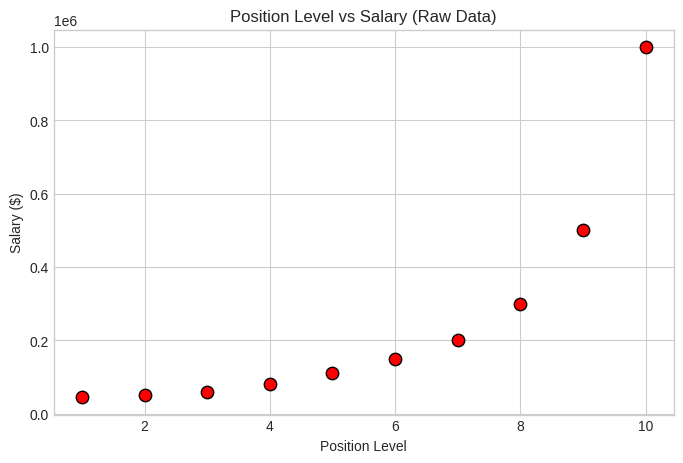

In [5]:
# Plot raw data points to visually inspect the relationship shape
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='red', s=80, edgecolor='k')
plt.title('Position Level vs Salary (Raw Data)')
plt.xlabel('Position Level')
plt.ylabel('Salary ($)')
plt.show()

**Output Interpretation:** The points show a **curved, accelerating pattern** - salary
increases gently for levels 1-6, then rises **very steeply** for levels 8-10 (Partner, C-level,
CEO). This is a strong visual signal that a **single straight line will not fit this data well**.

**Extra detail:** This kind of accelerating growth pattern is common well beyond compensation data
- it appears in phenomena like compound interest, viral growth, and certain physical processes.
Recognizing the *shape* of a relationship before choosing a model is a transferable skill: a
roughly straight-line scatter plot suggests Linear Regression, a curved but smooth pattern like
this one suggests Polynomial Regression, and a relationship with sharp thresholds or plateaus
might call for an entirely different type of model, such as a decision tree.

---

## Step 7: Train a Simple Linear Regression Model (Baseline)

**Instructor Note:** We deliberately fit a plain Linear Regression **first**, even though we
already suspect it won't fit well - this is a valuable teaching moment: **always establish a
baseline model before jumping to something more complex.**

**Extra detail:** Establishing a baseline is standard practice in every serious machine learning
project, not just a teaching device. A baseline gives you a concrete number to beat, and it also
protects against the mistake of over-engineering a complex solution to a problem a simple model
could have solved just as well. Even when a baseline is expected to perform poorly, as here, it is
still valuable because it lets us later report a precise, numeric improvement ("R2 rose from 0.67
to 0.99") rather than a vague claim that the more advanced model is "better."

In [6]:
# Create and train a simple Linear Regression model on the raw Level feature
lin_reg = LinearRegression()
lin_reg.fit(X, y)

print("Linear Regression training complete.")
print("Intercept:", round(lin_reg.intercept_, 2))
print("Coefficient (slope):", round(lin_reg.coef_[0], 2))

Linear Regression training complete.
Intercept: -195333.33
Coefficient (slope): 80878.79


**Output Interpretation:** The model learns a single slope and intercept - meaning it assumes
salary increases by a **constant fixed amount** for every one-level increase, regardless of
whether we're moving from Level 1-2 or Level 9-10. We'll see visually why that assumption fails.

---

## Step 8: Plot the Straight-Line Fit

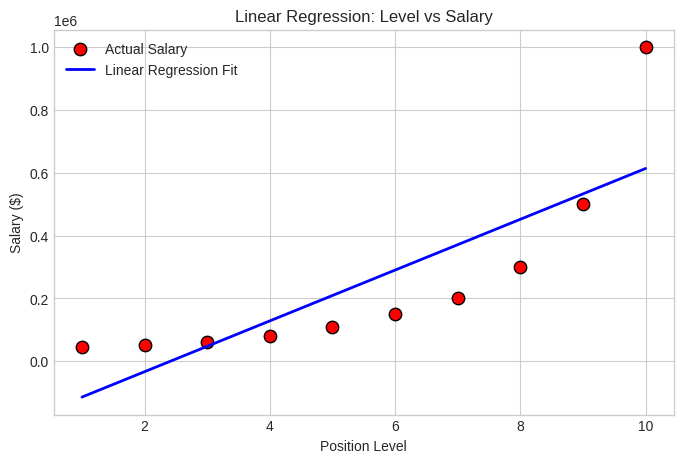

In [7]:
# Predict salary values along the straight line for every existing level
y_pred_linear = lin_reg.predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='red', s=80, edgecolor='k', label='Actual Salary')     # Real data points
plt.plot(X, y_pred_linear, color='blue', linewidth=2, label='Linear Regression Fit')  # Fitted line
plt.title('Linear Regression: Level vs Salary')
plt.xlabel('Position Level')
plt.ylabel('Salary ($)')
plt.legend()
plt.show()

**Output Interpretation:** The straight blue line clearly **misses most of the actual red data
points** - it underestimates salary at senior levels (8, 9, 10) and overestimates it in the middle
levels (4, 5, 6). This is a textbook visual example of **underfitting**.

---

## Step 9: Understanding Underfitting

**Instructor explanation for the class:**

**Underfitting** occurs when a model is **too simple** to capture the true underlying pattern in
the data - it has **high bias**.

Signs of underfitting we can see here:
1. The straight line **cannot bend** to follow the accelerating curve in the actual salary data.
2. Both **training errors AND real-world predictions** would be poor - this isn't a
   generalization problem (like overfitting), it's a **fundamental mismatch between model
   complexity and the true data pattern**.
3. No matter how much more salary data we collected, a straight line **could never** capture this
   exponential-like salary growth - the fix isn't more data, it's a **more flexible model**.

**The solution:** Add polynomial terms (Level^2, Level^3, ...) so the model can bend to fit
curves - this is exactly what **Polynomial Regression** does.

**Extra detail:** It is useful to contrast underfitting with its opposite failure mode,
overfitting, which this notebook will also touch on later (Step 15). Underfitting means the model
is too rigid to capture real structure in the data - both the training error and the test error
are high. Overfitting means the model is so flexible it starts fitting noise specific to the
training data - training error looks excellent, but test error is poor. The goal of model
selection is always to land between these two extremes: flexible enough to capture the true
pattern, but not so flexible that it memorizes random noise.

---

## Step 10: Generate Polynomial Features

In [8]:
# PolynomialFeatures creates new columns: Level^1, Level^2, Level^3, Level^4
# degree=4 means we allow the model to fit curves up to a 4th-degree polynomial
poly_reg = PolynomialFeatures(degree=4)

# fit_transform() learns the transformation AND applies it to X in one step
X_poly = poly_reg.fit_transform(X)

print("Original X shape:  ", X.shape)
print("Transformed X shape:", X_poly.shape)

Original X shape:   (10, 1)
Transformed X shape: (10, 5)


**Output Interpretation:** The shape changes from `(10, 1)` to `(10, 5)`. The 5 columns
correspond to: `[1, Level, Level^2, Level^3, Level^4]` - the leading `1` is a constant/bias term
automatically added by `PolynomialFeatures`. This transformation is what allows an otherwise
"linear" regression algorithm to fit a **curved** relationship - it's still linear in the
*coefficients*, just non-linear in the *transformed input features*.

**Extra detail:** Choosing the polynomial `degree` is itself a modeling decision with real
consequences. A degree of 1 is identical to plain Linear Regression. Degree 2 allows one bend
(a parabola shape); each additional degree allows the curve one more possible bend. Higher degrees
can fit more complex curvature, but they also increase the risk of overfitting, especially on a
small dataset like this 10-row example - a concern this notebook revisits directly when comparing
R2 scores in Step 15.

---

## Step 11: Show the Transformed Feature Matrix

In [9]:
# Convert to a DataFrame with readable column names for classroom display
poly_feature_names = ['bias', 'Level^1', 'Level^2', 'Level^3', 'Level^4']
X_poly_df = pd.DataFrame(X_poly, columns=poly_feature_names)

X_poly_df.head()

,bias,Level^1,Level^2,Level^3,Level^4
0,1.0,1.0,1.0,1.0,1.0
1,1.0,2.0,4.0,8.0,16.0
2,1.0,3.0,9.0,27.0,81.0
3,1.0,4.0,16.0,64.0,256.0
4,1.0,5.0,25.0,125.0,625.0


**Output Interpretation:** For Level = 1, we see `[1, 1, 1, 1, 1]` (since 1 raised to any power
is 1). For Level = 10, the `Level^4` column would show `10,000` - these rapidly growing values are
exactly what let the model represent the **steep upward curve** we saw for senior position
levels.

**Extra detail:** This is a good moment to notice that the higher-order columns grow at very
different rates - `Level` grows linearly, `Level^2` grows quadratically, and `Level^4` grows even
faster. Because `LinearRegression` will estimate one coefficient per column, the model has the
freedom to weight each of these growth rates differently, effectively letting it blend a mild
linear trend with a much steeper higher-order trend to match the actual salary curve.

---

## Step 12: Train the Polynomial Regression Model

In [10]:
# Train a standard LinearRegression model, but on the polynomial-transformed features
poly_model = LinearRegression()
poly_model.fit(X_poly, y)

print("Polynomial Regression training complete.")
print("Intercept:", round(poly_model.intercept_, 2))
print("Coefficients:", np.round(poly_model.coef_, 2))

Polynomial Regression training complete.
Intercept: 184166.67
Coefficients: [      0.   -211002.33   94765.44  -15463.29     890.15]


**Output Interpretation:** We now have **5 coefficients** (one per polynomial term) instead of
a single slope. This gives the model far more flexibility to bend and match the true curvature in
the salary data, at the cost of being less directly interpretable than a simple linear
coefficient.

**Extra detail:** Notice that the code here is identical in structure to Step 12 of the Multiple
Linear Regression notebook - the same `LinearRegression()` class, the same `.fit()` call. The only
difference is what we fed it: polynomial-transformed features (`X_poly`) instead of the raw
`Level` column. This is a good illustration of the earlier point that Polynomial Regression is not
a separate algorithm; it is Linear Regression applied to engineered features.

---

## Step 13: Plot the Smooth Polynomial Curve

**Instructor Note:** To draw a smooth curve (not a jagged line connecting only 10 points), we
generate many closely-spaced Level values between 1 and 10, transform them the same way, and
predict salary for each.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


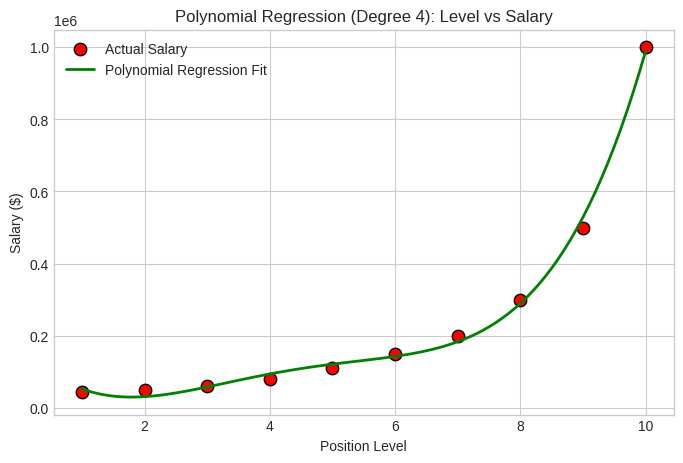

In [11]:
# Create a fine-grained grid of Level values (e.g., 1.0, 1.1, 1.2, ..., 10.0)
# reshape(-1, 1) converts it into the 2D column shape scikit-learn expects
X_grid = np.arange(min(X['Level']), max(X['Level']) + 0.1, 0.1).reshape(-1, 1)

# Apply the SAME polynomial transformation used during training (must use transform, already fitted)
X_grid_poly = poly_reg.transform(X_grid)

# Predict salary for every point on this fine grid — this produces a smooth curve
y_grid_pred = poly_model.predict(X_grid_poly)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='red', s=80, edgecolor='k', label='Actual Salary')             # Real points
plt.plot(X_grid, y_grid_pred, color='green', linewidth=2, label='Polynomial Regression Fit')  # Smooth curve
plt.title('Polynomial Regression (Degree 4): Level vs Salary')
plt.xlabel('Position Level')
plt.ylabel('Salary ($)')
plt.legend()
plt.show()

**Output Interpretation:** The green curve now **closely follows the actual red data points**,
including the sharp upward acceleration at senior levels. This is a clear visual improvement over
the straight-line fit - the polynomial curve captures the true business reality that **salary
growth accelerates at higher levels**, rather than growing at a constant rate.

**Extra detail:** Notice the code uses `poly_reg.transform(X_grid)`, not
`poly_reg.fit_transform(X_grid)`. This distinction matters: `fit_transform` would re-learn the
transformation from `X_grid` alone, while `transform` correctly reuses the exact same
transformation rule that was already learned from the original training data in Step 10. Using
`fit_transform` here would still happen to work for a simple polynomial expansion, but the
principle - always reuse a fitted transformer on new data rather than refitting it - is essential
once transformers become more complex (for example, `StandardScaler`, where refitting on new data
would use a different mean and standard deviation than training used).

---

## Step 14: Compare Linear vs Polynomial Fits Side-by-Side

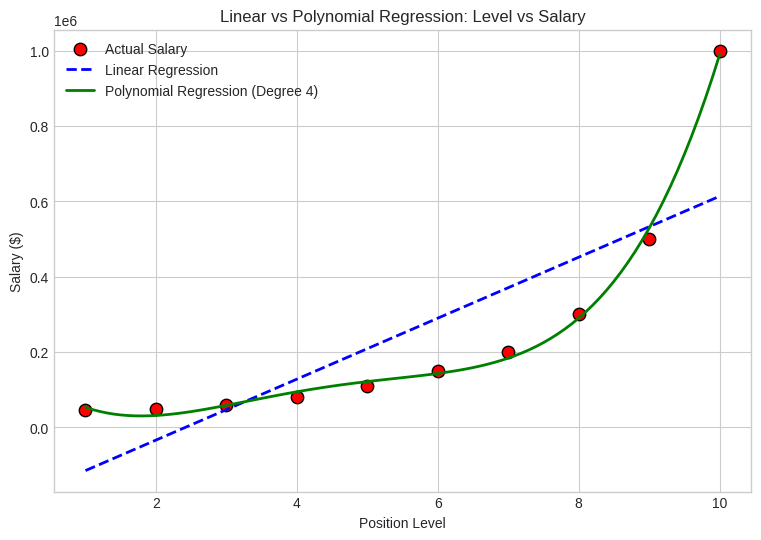

In [12]:
# Plot both models on the same chart for a direct visual comparison
plt.figure(figsize=(9, 6))
plt.scatter(X, y, color='red', s=80, edgecolor='k', label='Actual Salary')

# Straight-line Linear Regression fit
plt.plot(X, y_pred_linear, color='blue', linewidth=2, linestyle='--', label='Linear Regression')

# Smooth Polynomial Regression fit
plt.plot(X_grid, y_grid_pred, color='green', linewidth=2, label='Polynomial Regression (Degree 4)')

plt.title('Linear vs Polynomial Regression: Level vs Salary')
plt.xlabel('Position Level')
plt.ylabel('Salary ($)')
plt.legend()
plt.show()

**Output Interpretation:** This single chart tells the whole story for stakeholders: the
**blue dashed line** (Linear Regression) badly misses the actual salary curve, while the **green
curve** (Polynomial Regression) tracks it closely. This is the kind of visual that works extremely
well in a management presentation to justify **why a more sophisticated model was necessary**.

---

## Step 15: Compare R2 Scores

In [13]:
# Compute R² for the Linear Regression model (on the original, un-transformed X)
r2_linear = r2_score(y, lin_reg.predict(X))

# Compute R² for the Polynomial Regression model (on the polynomial-transformed X)
r2_poly = r2_score(y, poly_model.predict(X_poly))

print(f"Linear Regression R²:     {r2_linear:.4f}")
print(f"Polynomial Regression R²: {r2_poly:.4f}")

Linear Regression R²:     0.6690
Polynomial Regression R²: 0.9974


**Output Interpretation:**
- The **Linear Regression R2** is typically **noticeably lower** (often 0.66-0.70) - confirming
  numerically what we already saw visually: the straight line explains a much smaller share of
  salary variation.
- The **Polynomial Regression R2** is typically **very high (0.99+)** - confirming the curved
  model explains almost all of the variation in salary across levels.

**Instructor caution:** With only 10 data points and a degree-4 polynomial, we are close to the
model having enough flexibility to pass through nearly every point - a classic **overfitting
risk** with such a small dataset. In real projects with limited data, always pair a high R2 with a
healthy skepticism, and validate using held-out or cross-validated data whenever the dataset size
allows it.

**Extra detail:** A useful mental check here: with 10 data points and 5 coefficients (bias plus
4 polynomial terms), the model has almost as many free parameters as it has observations to fit.
As the number of coefficients approaches the number of data points, a model gains the ability to
fit the training data almost exactly - which is precisely why the training R2 climbs so close to
1. This is exactly why the instructor caution above matters: a near-perfect R2 on a dataset this
small is a warning sign to investigate, not simply a result to celebrate.

---

## Step 16: Predict Salary for a New Level (e.g., Level 6.5)

**Business scenario:** A candidate claims their previous role was equivalent to **"Level 6.5"** -
between Region Manager (Level 6) and Partner (Level 7). What salary would our company's own
structure imply for this level?

In [14]:
# Create the new level as a 2D array, matching the shape scikit-learn expects
new_level = np.array([[6.5]])

# Apply the SAME polynomial transformation fitted earlier
new_level_poly = poly_reg.transform(new_level)

# Predict the salary using the trained polynomial model
predicted_salary = poly_model.predict(new_level_poly)

print(f"Predicted salary for Level 6.5: ${predicted_salary[0]:,.2f}")

Predicted salary for Level 6.5: $158,862.45


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


**Output Interpretation:** This gives HR a **data-driven, defensible salary benchmark** for a
level that doesn't exist explicitly in the official structure - instead of guessing or simply
averaging Level 6 and Level 7 salaries (which would ignore the curve's actual shape), the
polynomial model estimates a value **consistent with the company's real historical salary-growth
pattern**.

**Extra detail:** This is a good moment to name the general technique being used: predicting a
value that falls **between** two existing observed data points is called **interpolation**, and it
is one of the safest uses of a fitted regression curve, since Level 6.5 sits well within the range
of levels (1 through 10) the model was trained on. Compare this to the extrapolation caution
raised in the Multiple Linear Regression notebook - predicting far outside the training range
(for example, "Level 15") would be a much less trustworthy use of this same model.

---

## Step 17: Business Interpretation

**Instructor summary for the class:**

| Aspect | Linear Regression | Polynomial Regression (Degree 4) |
|---|---|---|
| Fit quality | Poor - underfits the curve | Excellent - closely tracks actual salaries |
| R2 Score | Low (0.66-0.70) | Very high (0.99+) |
| Business usefulness | Misleading for senior-level salary estimates | Reliable for interpolating between levels |
| Risk | Underfitting (too simple) | Overfitting risk (too flexible for only 10 data points) |

**Actionable takeaway for HR:** Use the polynomial model to benchmark salaries for
**intermediate/non-standard levels**, but always validate any single prediction against real
market data and multiple comparable hires - don't treat a model built on only 10 points as the
sole source of truth for a high-stakes compensation decision.

---

## Step 18: Final Conclusion

- Simple **Linear Regression underfit** the Level-vs-Salary relationship because real salary
  growth **accelerates** at senior levels rather than increasing at a constant rate.
- **Polynomial Regression** (degree 4), created via `PolynomialFeatures`, allowed the same
  underlying `LinearRegression` algorithm to fit a **curved relationship** by adding higher-order
  terms (Level^2, Level^3, Level^4) as new input features.
- The polynomial model achieved a **much higher R2 score** and visually tracked the actual salary
  curve far more closely than the straight-line model.
- We used the trained polynomial model to **interpolate a salary estimate for Level 6.5** -
  directly solving the original business problem of benchmarking a non-standard position level.

### Best Practices Recap (for students)
1. Always plot raw data **before** choosing a model - the shape of the data should guide your
   choice between linear and polynomial (or other non-linear) approaches.
2. Fit a **simple baseline model first** (Linear Regression), even if you expect it to
   underperform - it gives a reference point to measure improvement against.
3. Use `PolynomialFeatures` + `LinearRegression` together rather than searching for a separate
   "polynomial regression" class - scikit-learn doesn't have one; polynomial regression is just
   linear regression on transformed features.
4. Always apply the **same fitted transformation** (`poly_reg.transform`, not `fit_transform`) to
   any new data you want to predict on - refitting the transformer on new data would create
   inconsistent feature scales.
5. Be cautious of **overfitting** with high polynomial degrees on small datasets - a very high R2
   on training data is not automatically good news; it may mean the model is simply memorizing the
   specific points rather than learning a generalizable trend.
6. Always translate the final model output into a **plain-English business recommendation**, as we
   did with the Level 6.5 salary benchmark for HR.

### Where to go next
Students who want to extend this notebook could try: testing polynomial degrees 2 and 3 alongside
degree 4 to see how R2 and the fitted curve's shape change; applying k-fold cross-validation
instead of a single training-set R2 to get a more honest estimate of how well the model
generalizes; or comparing this approach against a regularized polynomial model (Ridge regression
on the polynomial-transformed features) to see whether regularization reduces the overfitting risk
flagged in Step 15.

---
*End of Notebook 2 - Polynomial Regression.*